In [30]:
import pandas as pd
import pickle
import tensorflow as tf
from sklearn.metrics import accuracy_score
from tensorflow.keras import layers, Model

# Globals

In [31]:
LATENT_DIM = 8 
BATCH_SIZE = 2048

# Load dataset

In [32]:
df = pd.read_csv("/kaggle/input/vegemite-manufacturing-data/unnormalized.csv")

# Prepare Dataset

### Get columns indexes

In [33]:
SP_cols = [col for col in df.columns if "SP" in col]

In [34]:
original_features_order = df.drop("batch", axis=1).columns

## Scale dataset across all features (even categorical)

In [35]:
from sklearn.preprocessing import MinMaxScaler

mmscaler = MinMaxScaler()
tmp = mmscaler.fit_transform(df)
df = pd.DataFrame(tmp, columns=df.columns)
df

,Part,FFTE Feed solids SP,FFTE Production solids SP,FFTE Steam pressure SP,TFE Out flow SP,TFE Production solids SP,TFE Vacuum pressure SP,TFE Steam pressure SP,Extract tank Level,FFTE Discharge density,...,TFE Motor speed,TFE Out flow PV,TFE Production solids PV,TFE Production solids density,TFE Steam pressure PV,TFE Steam temperature,TFE Tank level,TFE Temperature,TFE Vacuum pressure PV,batch
0,0.0,1.0,0.5225,0.129095,0.464068,0.683673,0.170000,0.924812,0.610912,0.747573,...,1.0,0.108665,0.774108,0.741176,0.740085,0.663404,0.390195,0.333333,0.115178,1.0
1,0.0,1.0,0.5225,0.129095,0.464068,0.683673,0.170000,0.924812,0.415968,0.757282,...,1.0,0.104711,0.785736,0.847059,0.738191,0.663404,0.388423,0.314815,0.111381,1.0
2,0.0,1.0,0.5225,0.136905,0.464068,0.683673,0.170000,0.924812,0.340785,0.757282,...,1.0,0.127997,0.747696,0.847059,0.740085,0.610316,0.381926,0.296296,0.115178,1.0
3,0.0,1.0,0.5225,0.136905,0.464068,0.683673,0.171852,0.924812,0.255888,0.757282,...,1.0,0.076385,0.775902,0.847059,0.740085,0.610316,0.359953,0.333333,0.115178,1.0
4,0.5,1.0,0.0000,0.095238,0.537575,0.663265,0.166667,0.887218,0.624617,1.000000,...,1.0,0.038737,0.282675,0.694118,0.709779,0.775602,0.026226,0.351852,0.204303,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29275,0.5,1.0,0.7500,0.145537,0.462734,0.604073,0.187432,0.887218,0.746341,0.710209,...,1.0,0.095428,0.733013,0.788235,0.710299,0.723526,0.608397,0.370370,0.174723,1.0
29276,0.5,1.0,0.3750,0.134590,0.518150,0.653061,0.259421,0.924812,0.465635,0.543689,...,1.0,0.107645,0.759007,0.435294,0.740483,0.669083,0.855118,0.407407,0.171450,1.0
29277,0.5,1.0,0.3750,0.108402,0.630791,0.630948,0.193566,0.924812,0.770630,0.757282,...,1.0,0.146001,0.738763,0.458824,0.737865,0.583189,0.840786,0.296296,0.126367,1.0
29278,1.0,1.0,1.0000,0.090560,0.869499,0.540308,0.690732,0.887218,0.753426,0.757282,...,1.0,0.229480,0.702480,0.835294,0.711673,0.700301,0.839575,0.407407,0.215589,1.0


## Drop batch column, get SP features as y, other features as X

In [36]:
X = df[df["batch"] == 1.0].reset_index(drop=True)
y = X[SP_cols]
X = X.drop(SP_cols + ["batch"], axis=1)

## Pop batch to y for clf

In [37]:
y_clf = df.pop("batch").astype(int)

## Split train and test

In [38]:
from sklearn.model_selection import train_test_split

X_gan_train, X_gan_test, y_gan_train, y_gan_test = train_test_split(X, y, random_state=42, test_size=0.2)
X_clf, X_clf_test, y_clf, y_clf_test = train_test_split(df, y_clf, random_state=42, test_size=0.2)
X_gan_test.reset_index(inplace=True, drop=True)
y_gan_test.reset_index(inplace=True, drop=True)

## Format dataset as tf.data.Dataset

In [39]:
X_gan_cvt = tf.cast(X_gan_train, tf.float32)
y_gan_cvt = tf.cast(y_gan_train, tf.float32)

ds = tf.data.Dataset.from_tensor_slices((X_gan_cvt, y_gan_cvt))
test_ds = tf.data.Dataset.from_tensor_slices((X_gan_test, y_gan_test))

ds = ds.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## Get SP and sensors shape

In [40]:
sensors_shape = X.shape[1]
settings_shape = len(SP_cols)

# Train RandomForestClassifier for evaluation

In [41]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
clf.fit(X_clf, y_clf)
print(f"Training accuracy: {clf.score(X_clf, y_clf)}")
print(f"Test accuracy: {clf.score(X_clf_test, y_clf_test)}")

Training accuracy: 0.9409153005464481
Test accuracy: 0.9211065573770492


# Build Model

In [42]:
def generator_model():
    sensors_input = layers.Input(shape=(sensors_shape,))
    noise_input = layers.Input(shape=(LATENT_DIM,))
    
    x = layers.Concatenate()([sensors_input, noise_input])
    x = layers.Dense(2048)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dense(1024)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    out = layers.Dense(settings_shape, activation="sigmoid")(x)
    return Model(inputs=[noise_input, sensors_input], outputs=out, name="Generator")

generator = generator_model()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 23)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_5             │ (None, 8)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_2             │ (None, 31)             │              0 │ input_layer_4[0][0],   │
│ (Concatenate)             │                        │                │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (Dense)          │ (None, 2048)           │         65,536 │ concatenate_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 2048)           │          8,192 │ dense_10[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_8 (LeakyReLU) │ (None, 2048)           │              0 │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_11 (Dense)          │ (None, 1024)           │      2,098,176 │ leaky_re_lu_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 1024)           │          4,096 │ dense_11[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_9 (LeakyReLU) │ (None, 1024)           │              0 │ batch_normalization_5… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_12 (Dense)          │ (None, 512)            │        524,800 │ leaky_re_lu_9[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_6     │ (None, 512)            │          2,048 │ dense_12[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_10            │ (None, 512)            │              0 │ batch_normalization_6… │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_13 (Dense)          │ (None, 256)            │        131,328 │ leaky_re_lu_10[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_7     │ (None, 256)            │          1,024 │ dense_13[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_11            │ (None, 256)            │              0 │ batch_normalization_7… │
│ (LeakyReLU)               │                        │                │                        │
├──────────────────────

 Total params: 2,869,511 (10.95 MB)

 Trainable params: 2,861,575 (10.92 MB)

 Non-trainable params: 7,936 (31.00 KB)

In [43]:
def discriminator_model():
    sensors_input = layers.Input(shape=(sensors_shape,))
    settings_input = layers.Input(shape=(settings_shape,))
    
    x = layers.Concatenate()([sensors_input, settings_input])
    x = layers.Dense(2048)(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dense(1024)(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dense(128)(x)
    x = layers.LeakyReLU()(x)

    out = layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inputs=[settings_input, sensors_input], outputs=out)


discriminator = discriminator_model()
discriminator.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 23)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_7             │ (None, 7)              │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_3             │ (None, 30)             │              0 │ input_layer_6[0][0],   │
│ (Concatenate)             │                        │                │ input_layer_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_16 (Dense)          │ (None, 2048)           │         63,488 │ concatenate_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_13            │ (None, 2048)           │              0 │ dense_16[0][0]         │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_17 (Dense)          │ (None, 1024)           │      2,098,176 │ leaky_re_lu_13[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_14            │ (None, 1024)           │              0 │ dense_17[0][0]         │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_18 (Dense)          │ (None, 512)            │        524,800 │ leaky_re_lu_14[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_15            │ (None, 512)            │              0 │ dense_18[0][0]         │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_19 (Dense)          │ (None, 256)            │        131,328 │ leaky_re_lu_15[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_16            │ (None, 256)            │              0 │ dense_19[0][0]         │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_20 (Dense)          │ (None, 128)            │         32,896 │ leaky_re_lu_16[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ leaky_re_lu_17            │ (None, 128)            │              0 │ dense_20[0][0]         │
│ (LeakyReLU)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_21 (Dense)          │ (None, 1)              │            129 │ leaky_re_lu_17[0][0]   │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 2,850,817 (10.88 MB)

 Trainable params: 2,850,817 (10.88 MB)

 Non-trainable params: 0 (0.00 B)

# Optimizers

In [44]:
g_optim = tf.keras.optimizers.Adam(1e-5)
d_optim = tf.keras.optimizers.Adam(1e-5)

# Losses

In [45]:
bce = tf.keras.losses.BinaryCrossentropy()

In [46]:
def discriminator_loss(real_output, fake_output):
    real_loss = bce(tf.ones_like(real_output), real_output)
    fake_loss = bce(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss
def generator_loss(fake_output):
    return bce(tf.ones_like(fake_output), fake_output)

# Training

In [47]:
@tf.function
def generator_step(sensors_data):
    noise = tf.random.normal([tf.shape(sensors_data)[0], LATENT_DIM])

    with tf.GradientTape() as gen_tape:
        generated_settings = generator([noise, sensors_data], training=True)
        fake_output = discriminator([generated_settings, sensors_data], training=True)
        gen_loss = generator_loss(fake_output)

    gen_grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    g_optim.apply_gradients(zip(gen_grads, generator.trainable_variables))

    return gen_loss

@tf.function
def discriminator_step(sensors_data, actual_settings):
    noise = tf.random.normal([tf.shape(sensors_data)[0], LATENT_DIM])
    generated_settings = generator([noise, sensors_data], training=True)

    with tf.GradientTape() as disc_tape:
        real_output = discriminator([actual_settings, sensors_data], training=True)
        fake_output = discriminator([generated_settings, sensors_data], training=True)
        disc_loss = discriminator_loss(real_output, fake_output)

    disc_grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    d_optim.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    return disc_loss


In [48]:
from tqdm import tqdm
checkpoints = [100, 1000, 2000, 3000, 3500]
gen_losses = []
disc_losses = []

for epoch in range(4000):
    for batch in ds:
        sensors_data = batch[0] # (32, 23)
        # sensors_data = tf.convert_to_tensor(sensors_data, dtype=tf.float32)
        actual_settings = batch[1] # (32, 7)
        # actual_settings = tf.convert_to_tensor(actual_settings, dtype=tf.float32)

        gen_loss = generator_step(sensors_data)
            
        gen_losses.append(gen_loss.numpy())
        disc_loss = discriminator_step(sensors_data, actual_settings)
        disc_losses.append(disc_loss.numpy())
    if (epoch+1 in checkpoints):
        print(f"Epoch: {epoch+1}\nGenerator loss: {gen_loss}\nDiscriminator loss: {disc_loss}\n\n")

Epoch: 100
Generator loss: 2.1316699981689453
Discriminator loss: 0.9544816017150879


Epoch: 1000
Generator loss: 1.070338487625122
Discriminator loss: 1.1110634803771973


Epoch: 2000
Generator loss: 0.8318044543266296
Discriminator loss: 1.215808629989624


Epoch: 3000
Generator loss: 0.9008095860481262
Discriminator loss: 1.188808798789978


Epoch: 3500
Generator loss: 1.088361144065857
Discriminator loss: 1.191078782081604




# Evaluation

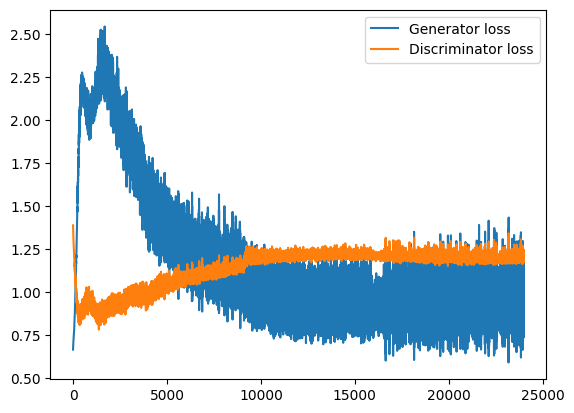

In [49]:
import matplotlib.pyplot as plt

plt.plot(gen_losses, label="Generator loss")
plt.plot(disc_losses, label="Discriminator loss")
plt.legend()
plt.show()

In [50]:
def evaluate_model(generator, discriminator, train_ds, test_ds):
    train_preds = []
    test_preds = []

    for batch in train_ds:
        sensors = batch[0]
        actual_settings = batch[0]
        noise = tf.random.normal([sensors.shape[0], LATENT_DIM])
        train_preds.append(generator([noise, sensors]))
    for batch in test_ds:
        sensors = batch[0]
        actual_settings = batch[0]
        noise = tf.random.normal([sensors.shape[0], LATENT_DIM])
        test_preds.append(generator([noise, sensors]))

    preds_numpy = tf.concat(train_preds, axis=0).numpy()
    train_preds_df = pd.DataFrame(preds_numpy, columns=SP_cols)
    train_preds_df = pd.concat([train_preds_df, X_gan_train.reset_index(drop=True)], axis=1)

    preds_numpy = tf.concat(test_preds, axis=0).numpy()
    test_preds_df = pd.DataFrame(preds_numpy, columns=SP_cols)
    test_preds_df = pd.concat([test_preds_df, X_gan_test.reset_index(drop=True)], axis=1)

    train_preds_df = train_preds_df[original_features_order]
    test_preds_df = test_preds_df[original_features_order]

    orig_data_train = pd.concat([X_gan_train, y_gan_train], axis=1)
    orig_data_test = pd.concat([X_gan_test, y_gan_test], axis=1)
    orig_data_train = orig_data_train[original_features_order]
    orig_data_test = orig_data_test[original_features_order]

    y_true_train = clf.predict(orig_data_train)
    y_pred_train = clf.predict(train_preds_df)
    y_true_test = clf.predict(orig_data_test)
    y_pred_test = clf.predict(test_preds_df)

    print("Accuracy for training dataset: ", accuracy_score(y_true_train, y_pred_train))
    print("Accuracy for test dataset: ", accuracy_score(y_true_test, y_pred_test))

In [51]:
train_preds = []
test_preds = []

for batch in ds:
    sensors = batch[0]
    actual_settings = batch[1]
    noise = tf.random.normal([sensors.shape[0], LATENT_DIM])
    train_preds.append(generator([noise, sensors]))

for batch in test_ds:
    sensors = batch[0]
    actual_settings = batch[1]
    noise = tf.random.normal([sensors.shape[0], LATENT_DIM])
    test_preds.append(generator([noise, sensors]))    

### Format 

In [52]:
preds_numpy = tf.concat(train_preds, axis=0).numpy()
train_preds_df = pd.DataFrame(preds_numpy, columns=SP_cols)
train_preds_df = pd.concat([train_preds_df, X_gan_train.reset_index(drop=True)], axis=1)

preds_numpy = tf.concat(test_preds, axis=0).numpy()
test_preds_df = pd.DataFrame(preds_numpy, columns=SP_cols)
test_preds_df = pd.concat([test_preds_df, X_gan_test.reset_index(drop=True)], axis=1)

In [53]:
train_preds_df = train_preds_df[original_features_order]
test_preds_df = test_preds_df[original_features_order]

Test dataset


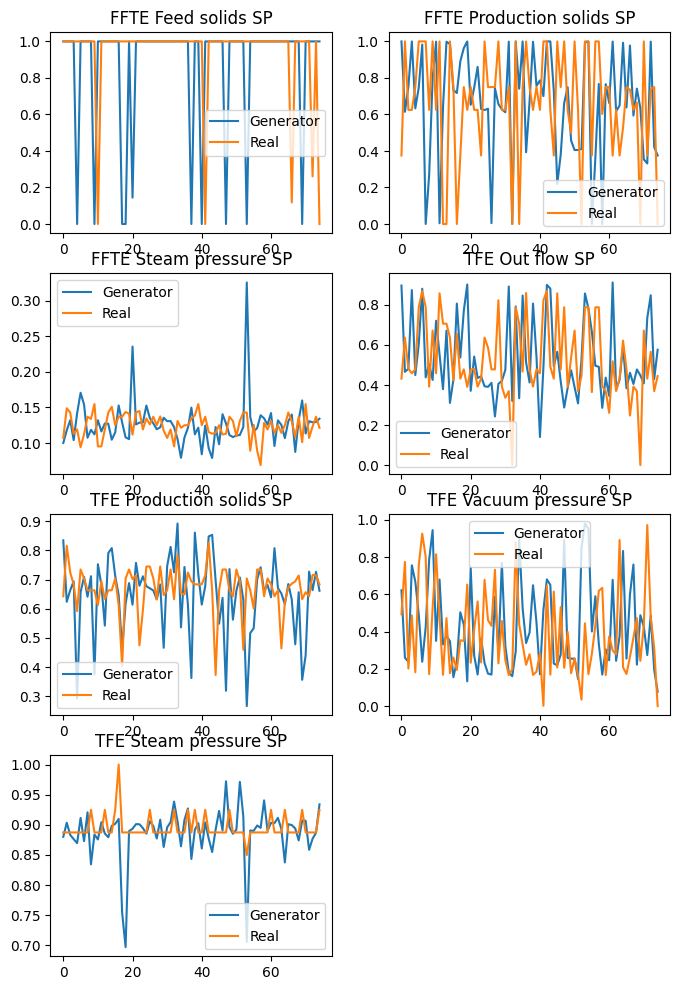

In [54]:
print("Test dataset")
plt.figure(figsize=(8, 12))
for i, col in enumerate(SP_cols):
    plt.subplot(4, 2, i+1)
    plt.title(col)
    plt.plot(test_preds_df[col][:75], label="Generator")
    plt.plot(y_gan_test[col][:75], label="Real")
    plt.legend()


In [55]:
orig_data_train = pd.concat([X_gan_train, y_gan_train], axis=1)
orig_data_test = pd.concat([X_gan_test, y_gan_test], axis=1)

orig_data_train = orig_data_train[original_features_order]
orig_data_test = orig_data_test[original_features_order]

In [56]:
y_true_train = clf.predict(orig_data_train)
y_pred_train = clf.predict(train_preds_df)
y_true_test = clf.predict(orig_data_test)
y_pred_test = clf.predict(test_preds_df)

In [57]:
print("Accuracy for training dataset: ", accuracy_score(y_true_train, y_pred_train))
print("Accuracy for test dataset: ", accuracy_score(y_true_test, y_pred_test))

Accuracy for training dataset:  0.7787739071038251
Accuracy for test dataset:  0.764344262295082


In [58]:
generator.save("generator.keras")